# Emotion Detection from Text — Training & Evaluation

**Project:** Emotion Detection from Text (tweet-level, 13 emotion classes)
**Model:** TF-IDF features + a linear classifier (logistic regression trained epoch-by-epoch)

This notebook is an **orchestration notebook**: all real logic (data loading, cleaning, splitting, model definition, training loop, evaluation) lives in the `src/` package. This notebook only imports those functions, sets configuration, and calls them in order.

**Sections:**
1. Imports & configuration
2. Load the dataset
3. Data sanity check (before cleaning)
4. Explore the dataset
5. Clean the text
6. Data sanity check (after cleaning)
7. Train / validation / test split
8. Build the model (vectorizer + classifier)
9. Train and validate (epoch loop)
10. Training curves
11. Final evaluation on the test set
12. Save the trained model
13. Try the model on your own sentences

## 1. Imports & Configuration

`src/config.py` holds every file path and hyperparameter used below. Change values there, not in this notebook.

In [4]:
from src import config
from src.data_loader import load_dataset, get_class_counts
from src.data_sanity_check import run_sanity_checks
from src.text_cleaner import clean_dataframe
from src.data_splitter import split_data
from src.model_builder import build_vectorizer, build_classifier, combine_into_pipeline
from src.training_pipeline import train_and_validate
from src.evaluator import plot_training_curves, evaluate_model, plot_confusion_matrix
from src.model_io import save_model
from src.predictor import predict_emotion

## 2. Load the Dataset

In [5]:
df = load_dataset(config.DATA_PATH)
df.head()
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows removed.")
print("Remaining rows:", len(df))

Duplicate rows removed.
Remaining rows: 40000


## 3. Data Sanity Check (Raw Data)

Before doing anything else, check the raw data for missing values, missing labels, and duplicate rows.

In [6]:
_ = run_sanity_checks(df, text_column=config.TEXT_COLUMN, label_column=config.LABEL_COLUMN)

DATA SANITY CHECK
----------------------------------------
total_rows: 40000
missing_text: 0
missing_labels: 0
duplicate_rows: 91
unique_labels: ['anger', 'boredom', 'empty', 'enthusiasm', 'fun', 'happiness', 'hate', 'love', 'neutral', 'relief', 'sadness', 'surprise', 'worry']
----------------------------------------
PASSED: no missing text or labels.


In [8]:
# 1. Define the list of labels you want to drop
labels_to_remove = ['anger', 'boredom', 'empty', 'enthusiasm', 'fun']

# 2. Filter the DataFrame to keep only the rows NOT in that list
df = df[~df[config.LABEL_COLUMN].isin(labels_to_remove)]

# 3. Verify the new row count
print(f"Total rows after filtering: {len(df)}")


Total rows after filtering: 36349


## 4. Explore the Dataset

How many tweets exist for each emotion? Some emotions (like `anger` and `boredom`) have very few examples — that class imbalance is expected, but it means the model will find those emotions harder to learn.

In [10]:
class_counts = get_class_counts(df, label_column=config.LABEL_COLUMN)
class_counts

sentiment
neutral      8638
worry        8459
happiness    5209
sadness      5165
love         3842
surprise     2187
relief       1526
hate         1323
Name: count, dtype: int64

<Axes: title={'center': 'Number of Tweets per Emotion'}, xlabel='sentiment'>

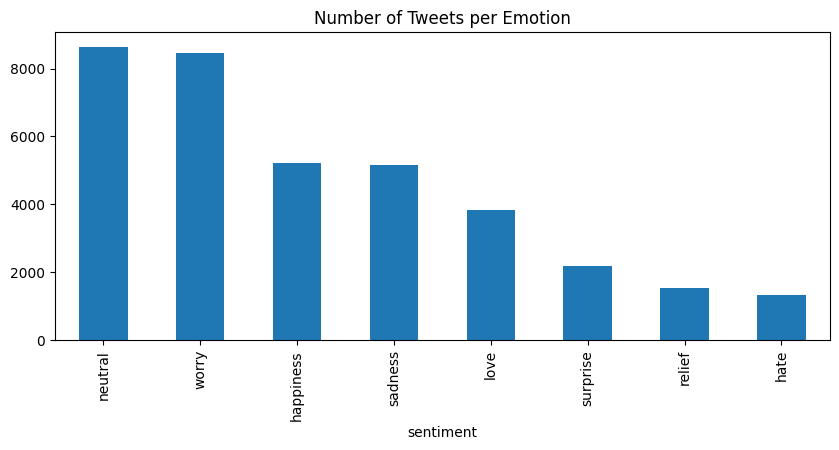

In [11]:
class_counts.plot(kind="bar", figsize=(10, 4), title="Number of Tweets per Emotion")

## 5. Clean the Text

Raw tweets contain links, @mentions, hashtags, and punctuation. `clean_dataframe()` cleans all of that and stores the result in a new column.

In [12]:
df = clean_dataframe(df, text_column=config.TEXT_COLUMN, new_column=config.CLEAN_TEXT_COLUMN)
df[[config.TEXT_COLUMN, config.CLEAN_TEXT_COLUMN, config.LABEL_COLUMN]].head()

,content,clean_text,sentiment
1,Layin n bed with a headache ughhhh...waitin o...,layin n bed with a headache ughhhh waitin on y...,sadness
2,Funeral ceremony...gloomy friday...,funeral ceremony gloomy friday,sadness
4,@dannycastillo We want to trade with someone w...,we want to trade with someone who has houston ...,neutral
5,Re-pinging @ghostridah14: why didn't you go to...,re pinging why didn t you go to prom bc my bf ...,worry
6,"I should be sleep, but im not! thinking about ...",i should be sleep but im not thinking about an...,sadness


## 6. Data Sanity Check (Cleaned Data)

Run the sanity check again, this time also checking whether any tweets became an empty string after cleaning (e.g. a tweet that was just a URL).

In [13]:
_ = run_sanity_checks(
    df,
    text_column=config.TEXT_COLUMN,
    label_column=config.LABEL_COLUMN,
    clean_text_column=config.CLEAN_TEXT_COLUMN,
)

DATA SANITY CHECK
----------------------------------------
total_rows: 36349
missing_text: 0
missing_labels: 0
duplicate_rows: 91
unique_labels: ['happiness', 'hate', 'love', 'neutral', 'relief', 'sadness', 'surprise', 'worry']
empty_after_cleaning: 84
----------------------------------------
PASSED: no missing text or labels.


## 7. Train / Validation / Test Split

- **Train** — the model learns from this.
- **Validation** — checked after every training epoch to track learning progress.
- **Test** — untouched until the very end, for a final unbiased evaluation.

In [14]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    df,
    text_column=config.CLEAN_TEXT_COLUMN,
    label_column=config.LABEL_COLUMN,
    val_size=config.VAL_SIZE,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 25444
Validation: 3635
Test: 7270


## 8. Build the Model

Two untrained pieces: a TF-IDF vectorizer (text -> numbers) and a linear classifier (numbers -> emotion).

In [15]:
vectorizer = build_vectorizer(max_features=config.MAX_FEATURES, ngram_range=config.NGRAM_RANGE)
classifier = build_classifier(
    alpha=config.ALPHA,
    learning_rate=config.LEARNING_RATE,
    random_state=config.RANDOM_STATE,
)

## 9. Train and Validate

Trains for `config.EPOCHS` epochs. After every epoch we print train/validation accuracy and loss.

In [16]:
classifier, vectorizer, history = train_and_validate(
    vectorizer, classifier,
    X_train, y_train,
    X_val, y_val,
    epochs=config.EPOCHS,
)

Epoch  1/15 - train_acc: 0.452 - val_acc: 0.384 - train_loss: 1.533 - val_loss: 1.651
Epoch  2/15 - train_acc: 0.459 - val_acc: 0.390 - train_loss: 1.526 - val_loss: 1.643
Epoch  3/15 - train_acc: 0.463 - val_acc: 0.394 - train_loss: 1.525 - val_loss: 1.641
Epoch  4/15 - train_acc: 0.464 - val_acc: 0.392 - train_loss: 1.525 - val_loss: 1.641
Epoch  5/15 - train_acc: 0.465 - val_acc: 0.394 - train_loss: 1.524 - val_loss: 1.640
Epoch  6/15 - train_acc: 0.464 - val_acc: 0.394 - train_loss: 1.524 - val_loss: 1.640
Epoch  7/15 - train_acc: 0.464 - val_acc: 0.393 - train_loss: 1.524 - val_loss: 1.640
Epoch  8/15 - train_acc: 0.464 - val_acc: 0.392 - train_loss: 1.524 - val_loss: 1.640
Epoch  9/15 - train_acc: 0.464 - val_acc: 0.392 - train_loss: 1.524 - val_loss: 1.640
Epoch 10/15 - train_acc: 0.464 - val_acc: 0.393 - train_loss: 1.524 - val_loss: 1.640
Epoch 11/15 - train_acc: 0.464 - val_acc: 0.392 - train_loss: 1.524 - val_loss: 1.640
Epoch 12/15 - train_acc: 0.464 - val_acc: 0.393 - trai

## 10. Training Curves

If validation accuracy flattens out (or validation loss starts rising) while train accuracy keeps improving, that's a sign of overfitting.

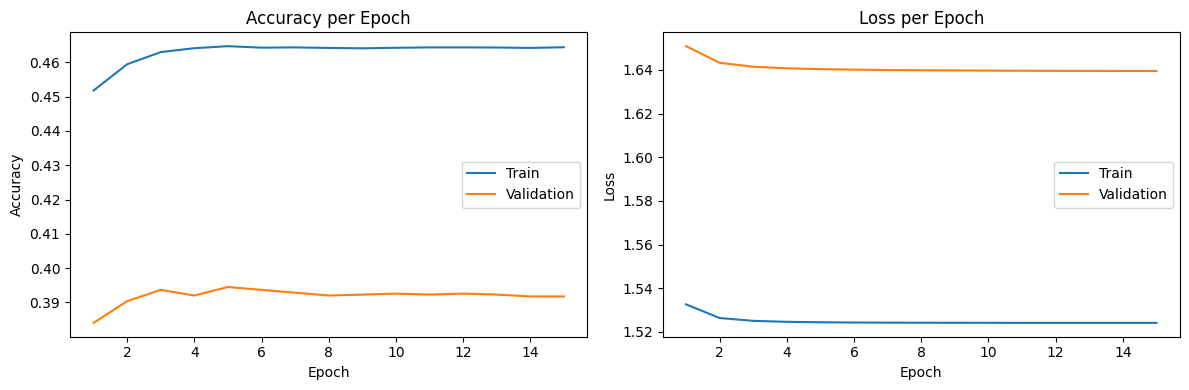

In [17]:
plot_training_curves(history)

## 11. Final Evaluation on the Test Set

The test set was never touched during training or validation, so this is our best estimate of how the model performs on brand-new tweets.

In [18]:
model = combine_into_pipeline(vectorizer, classifier)
y_pred = evaluate_model(model, X_test, y_test)

Accuracy: 38.23%

Classification Report:
              precision    recall  f1-score   support

   happiness       0.41      0.32      0.36      1042
        hate       0.53      0.07      0.12       265
        love       0.53      0.34      0.41       768
     neutral       0.37      0.60      0.46      1728
      relief       0.50      0.01      0.01       305
     sadness       0.39      0.18      0.24      1033
    surprise       0.50      0.01      0.02       437
       worry       0.35      0.55      0.43      1692

    accuracy                           0.38      7270
   macro avg       0.45      0.26      0.26      7270
weighted avg       0.41      0.38      0.35      7270



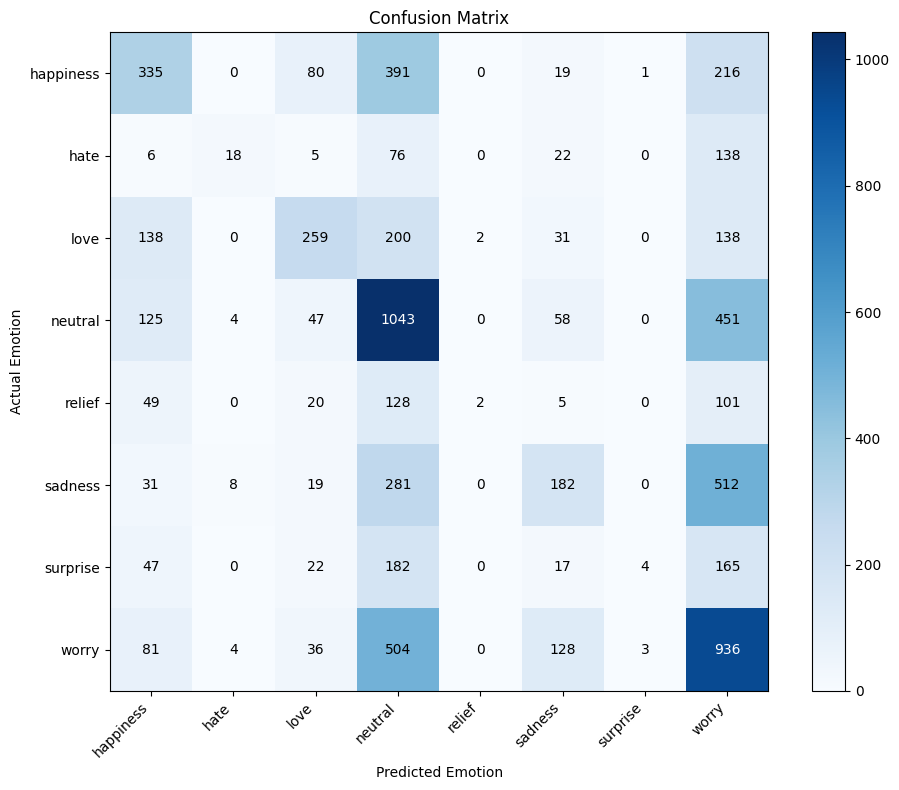

In [19]:
emotion_labels = sorted(df[config.LABEL_COLUMN].unique())
plot_confusion_matrix(y_test, y_pred, labels=emotion_labels)

## 12. Save the Trained Model

In [20]:
save_model(model, path=config.MODEL_SAVE_PATH)

Model saved to: models/emotion_model.pkl


## 13. Try the Model on Your Own Sentences

In [21]:
my_sentences = [
    "I am so happy today, everything is going great!",
    "I can't believe this happened, I'm furious right now.",
    "I feel so alone and sad tonight.",
]

predictions = predict_emotion(model, my_sentences)

for sentence, emotion in zip(my_sentences, predictions):
    print(f"{emotion:12s} -> {sentence}")

happiness    -> I am so happy today, everything is going great!
worry        -> I can't believe this happened, I'm furious right now.
sadness      -> I feel so alone and sad tonight.
